# 01 - Training Smoke Run And TensorBoard

**Goal:** Prove the training stack works before spending hours on final runs.

**What you will learn:** How to run a short PPO job, inspect logs, read `progress.csv`, find checkpoints, and test resume.

**Inputs:** The `soccertwos` environment with Ray/RLlib installed.

**Outputs:** A smoke checkpoint, Ray progress table, optional TensorBoard process, and run metadata.

**Success criteria:** `run_metadata.json`, `progress.csv`, and at least one checkpoint are created or a clear dependency error is printed.

In [7]:
from pathlib import Path
import importlib
import os
import sys

PROJECT_MARKER = Path("soccer_twos_project") / "notebook_tools.py"


def _running_in_colab():
    if "google.colab" in sys.modules:
        return True
    if os.environ.get("COLAB_RELEASE_TAG") or os.environ.get("COLAB_GPU"):
        return True
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return False


def _candidate_project_roots():
    seen = set()

    def add(path):
        path = Path(path).expanduser()
        key = str(path)
        if key not in seen:
            seen.add(key)
            yield path

    for env_name in ("SOCCER_TWOS_PROJECT_ROOT", "PROJECT_ROOT"):
        value = os.environ.get(env_name)
        if value:
            yield from add(value)

    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        yield from add(base)
        yield from add(base / "soccer-twos-starter")
        yield from add(base / "project" / "soccer-twos-starter")

    if sys.platform == "darwin":
        yield from add(
            Path.home()
            / "all_data"
            / "Georgia Tech"
            / "Course Content"
            / "CS 8803- DRL"
            / "project"
            / "soccer-twos-starter"
        )

    if _running_in_colab():
        try:
            from google.colab import drive  # type: ignore
            if not Path("/content/drive/MyDrive").exists():
                drive.mount("/content/drive")
        except Exception:
            pass
        for drive_root in (Path("/content/drive/MyDrive"), Path("/content/drive/Shareddrives"), Path("/content")):
            for relative in (
                Path("CS 8803- DRL") / "project" / "soccer-twos-starter",
                Path("project") / "soccer-twos-starter",
                Path("soccer-twos-starter"),
                Path("Colab Notebooks") / "soccer-twos-starter",
            ):
                yield from add(drive_root / relative)


def _find_project_root():
    for candidate in _candidate_project_roots():
        if (candidate / PROJECT_MARKER).exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not find soccer_twos_project/notebook_tools.py. "
        "Open this notebook from the project root/notebooks folder, or set SOCCER_TWOS_PROJECT_ROOT."
    )


PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for _module_name in list(sys.modules):
    if _module_name == "soccer_twos_project" or _module_name.startswith("soccer_twos_project."):
        del sys.modules[_module_name]

importlib.invalidate_caches()
from IPython.display import Markdown, display
from soccer_twos_project.notebook_tools import *

ctx = setup_project()
show_hardware()

Runtime: linux
Project root: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter
Artifact root: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos
Python: /coc/scratch/dgarg/miniconda3/envs/soccertwos/bin/python
soccer_twos: /coc/scratch/dgarg/miniconda3/envs/soccertwos/lib/python3.8/site-packages/soccer_twos/__init__.py
ray: 1.13.0
torch: 1.8.1+cu111
python: /coc/scratch/dgarg/miniconda3/envs/soccertwos/bin/python
{
  "cpu_count": 128,
  "gpu_name": "NVIDIA A40",
  "mlx_available": false,
  "ram_gb": 503.69,
  "torch_cuda_available": true,
  "torch_cuda_device_count": 8,
  "torch_cuda_device_names": [
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40",
    "NVIDIA A40"
  ],
  "torch_cuda_runtime_probe_device": "NVIDIA A40",
  "torch_cuda_runtime_probe_error": "",
  "torch_cuda_runtime_ready": true,
  "torch_cuda_version": "11.1",
  "torch_mps_available": false,
  "

## Configuration

This smoke job is for validation, not performance. Increase timesteps only after this notebook succeeds.

In [8]:
# ── Quick training test config ────────────────────────────────────────────
# Goal: Run enough iterations to see if the reward curve rises.
# a40_full: 1 GPU + 40 workers, 80K batch → ~6 PPO iterations per 500K steps.
# Expected wall-clock time: ~8-15 minutes on the A40 cluster.
# ──────────────────────────────────────────────────────────────────────────
RUN_SMOKE_TRAINING = True
PROFILE_NAME = "a40_full"    # 1 GPU + 40 workers, 80K batch (was: a40, 16 workers, 32K)
SMOKE_TIMESTEPS = 500_000    # ~6 PPO iterations — enough to see early learning signal
RUN_RESUME_TEST = False
RESUME_TIMESTEPS = 600_000
RUN_TENSORBOARD = True       # watch reward curves live at http://localhost:6006


## Optional TensorBoard

TensorBoard reads Ray event files under the checkpoint artifact directory.

In [9]:
print("TensorBoard logdir:", ctx.dirs["checkpoints"])
if RUN_TENSORBOARD:
    tensorboard_proc = launch_tensorboard(ctx, port=6006)
else:
    print("Set RUN_TENSORBOARD=True to launch TensorBoard at http://localhost:6006.")

TensorBoard logdir: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints
TensorBoard command: /coc/scratch/dgarg/miniconda3/envs/soccertwos/bin/python -m tensorboard.main --logdir /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints --port 6006 --reload_interval 10
Open: http://localhost:6006
PID: 204641


## Run The Smoke Job

This should create a checkpoint, TensorBoard event files, `progress.csv`, and valid `run_metadata.json`.

2026-04-23 08:35:03,390	INFO tune.py:747 -- Total run time: 162.10 seconds (161.31 seconds for the tuning loop).


Best trial: PPO_Soccer_79595_00000
Best checkpoint: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/checkpoint_000006/checkpoint-6
Wrote run metadata: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/run_metadata.json
Returned checkpoint: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/checkpoint_000006/checkpoint-6

Inline progress summary for ppo_baseline
Latest progress file: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/progress.csv


,training_iteration,timesteps_total,episodes_total,episode_reward_mean,episode_reward_min,episode_reward_max,episode_len_mean,time_total_s
0,1,80000,80,-0.019290,-2.0,1.8516,978.9625,20.183629
1,2,160000,161,-0.108312,-2.0,1.1688,968.5500,40.268979
2,3,240000,241,-0.094040,-2.0,1.1688,965.5900,60.428908
3,4,320000,321,-0.011664,-2.0,1.9552,977.7800,79.498897
4,5,400000,401,-0.004420,-2.0,1.3524,988.2100,101.844866
5,6,480000,482,0.028428,0.0,1.8036,985.7800,123.099359
6,7,560000,563,-0.024184,-2.0,1.9468,974.8400,141.567081


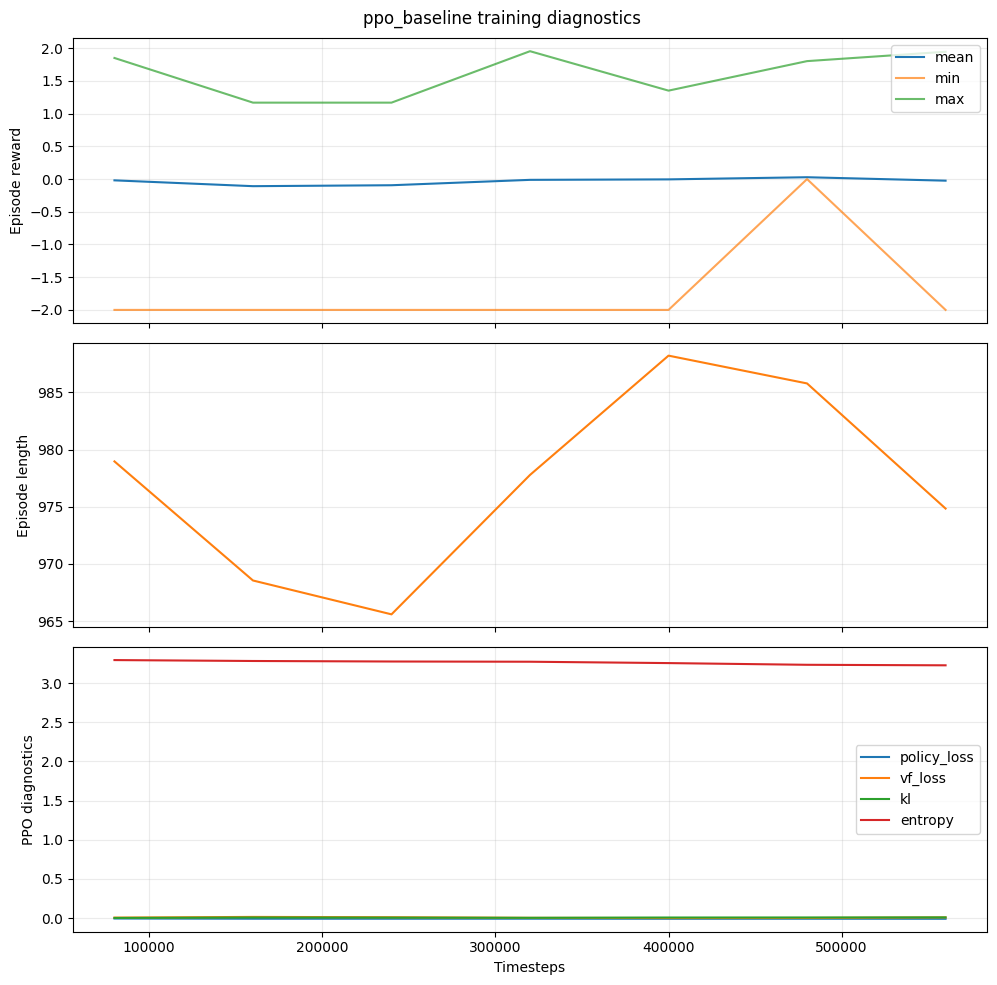

{'ppo_baseline': '/coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/checkpoint_000006/checkpoint-6'}

In [10]:
# Smoke test: run only ppo_baseline to validate the training stack.
# This is NOT a full training run — it just proves env launch, Ray, logging,
# and checkpointing work before you commit GPU-hours to production runs.
smoke_checkpoints = {}
if RUN_SMOKE_TRAINING:
    for stage in ["ppo_baseline"]:  # smoke: single stage only
        try:
            smoke_checkpoints[stage] = run_training(
                ctx,
                stage=stage,
                profile_name=PROFILE_NAME,
                timesteps=SMOKE_TIMESTEPS,
                smoke=False,
                checkpoint_freq=1,
                verbose=1,
            )
            print(f"\nInline progress summary for {stage}")
            show_training_snapshot(
                ctx,
                stage,
                rows=10,
                title=f"{stage} training diagnostics",
            )
        except Exception as exc:
            print(f"Smoke training failed for {stage}:", type(exc).__name__, exc)
else:
    print("RUN_SMOKE_TRAINING=False. Looking for an existing smoke checkpoint.")

smoke_checkpoint = smoke_checkpoints.get("ppo_baseline")
if smoke_checkpoint is None:
    try:
        smoke_checkpoint = best_checkpoint(ctx, "ppo_baseline")
        print("Using existing checkpoint:", smoke_checkpoint)
    except Exception as exc:
        print("No checkpoint available yet:", type(exc).__name__, exc)

smoke_checkpoints


## Inspect Progress And Checkpoints

Early reward can be flat. Here the success signal is that logging and metadata exist.

Latest progress file: /coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/progress.csv


,training_iteration,timesteps_total,episodes_total,episode_reward_mean,episode_reward_min,episode_reward_max,episode_len_mean,time_total_s
0,1,80000,80,-0.019290,-2.0,1.8516,978.9625,20.183629
1,2,160000,161,-0.108312,-2.0,1.1688,968.5500,40.268979
2,3,240000,241,-0.094040,-2.0,1.1688,965.5900,60.428908
3,4,320000,321,-0.011664,-2.0,1.9552,977.7800,79.498897
4,5,400000,401,-0.004420,-2.0,1.3524,988.2100,101.844866
5,6,480000,482,0.028428,0.0,1.8036,985.7800,123.099359
6,7,560000,563,-0.024184,-2.0,1.9468,974.8400,141.567081


{
  "checkpoint": "/coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/checkpoint_000006/checkpoint-6",
  "criterion": "policy performance baseline",
  "exists": true,
  "experiment": "Soccer",
  "stage": "ppo_baseline",
  "stop": {
    "timesteps_total": 500000
  }
}
{
  "algo": "PPO",
  "best_checkpoint": "/coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/checkpoint_000006/checkpoint-6",
  "criterion": "policy performance baseline",
  "stage": "ppo_baseline",
  "stop": {
    "timesteps_total": 500000
  }
}


{'algo': 'PPO',
 'best_checkpoint': '/coc/scratch/vchopra/rl_training/project/soccer-twos-starter/artifacts/cs8803_soccer_twos/checkpoints/soccer_ppo_baseline/PPO_Soccer_79595_00000_0_2026-04-23_08-32-21/checkpoint_000006/checkpoint-6',
 'best_trial': 'PPO_Soccer_79595_00000',
 'config': {'env': 'Soccer',
  'env_config': {'base_port': 50039,
   'flatten_branched': True,
   'multiagent': False,
   'num_envs_per_worker': 1,
   'opponent_policy': '<function base_env_config.<locals>.<lambda> at 0x7906bc5c5160>',
   'render': False,
   'single_player': True,
   'variation': "<EnvType.team_vs_policy: 'team_vs_policy'>"},
  'framework': 'torch',
  'grad_clip': 0.5,
  'log_level': 'INFO',
  'model': {'fcnet_activation': 'relu',
   'fcnet_hiddens': [512],
   'vf_share_layers': True},
  'num_envs_per_worker': 1,
  'num_gpus': 1,
  'num_workers': 40,
  'rollout_fragment_length': 2000,
  'sgd_minibatch_size': 8000,
  'train_batch_size': 80000},
 'criterion': 'policy performance baseline',
 'cuda_t

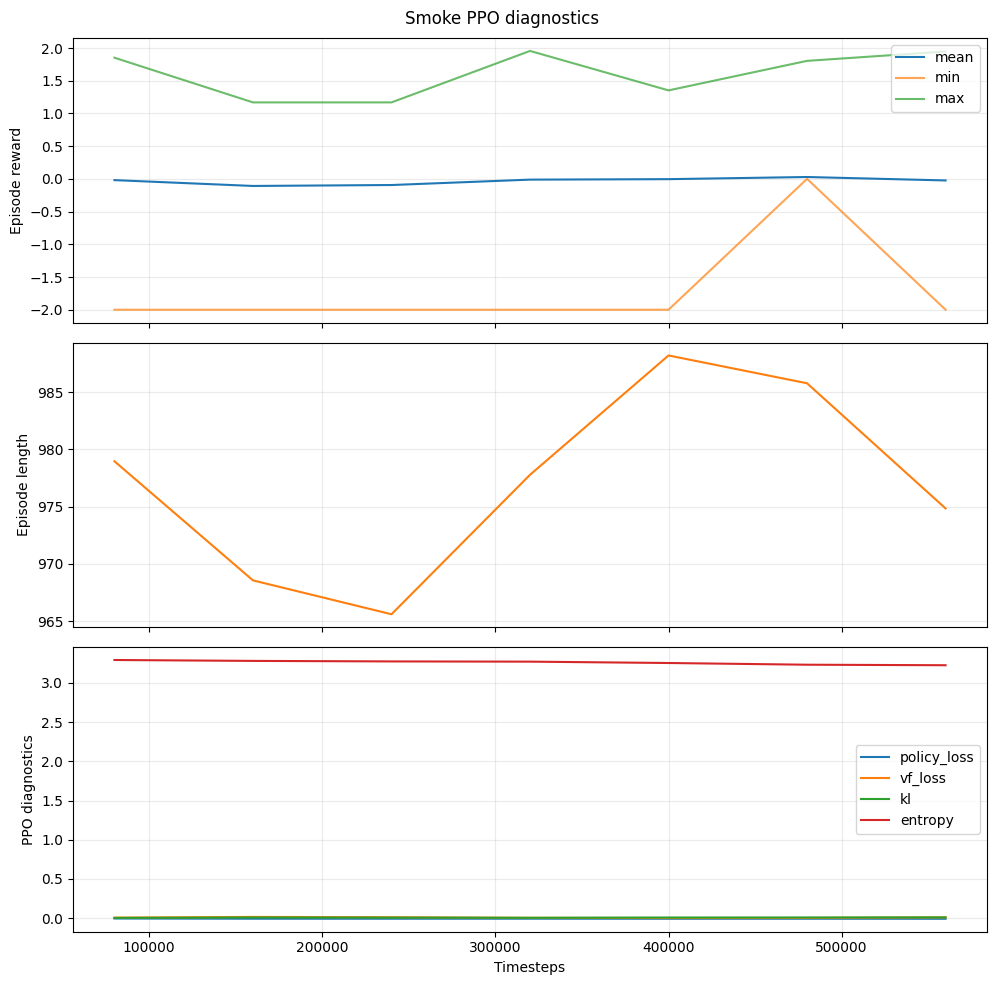

In [11]:
progress_df = load_progress_table(ctx, "ppo_baseline")
if progress_df.empty:
    print("No progress.csv yet.")
else:
    display(progress_status(ctx, "ppo_baseline", rows=10))
    plot_training_diagnostics(progress_df, title="Smoke PPO diagnostics");
print_json(checkpoint_summary(ctx, "ppo_baseline"))
run_metadata_status(ctx, "ppo_baseline")

## Resume Sanity

Resume is guarded by a boolean so you can run it only after the first checkpoint exists.

In [12]:
resumed_checkpoint = None
if RUN_RESUME_TEST and smoke_checkpoint:
    try:
        resumed_checkpoint = run_training(
            ctx,
            stage="ppo_baseline",
            profile_name="auto",
            timesteps=RESUME_TIMESTEPS,
            smoke=True,
            restore=smoke_checkpoint,
            checkpoint_freq=1,
            verbose=1,
        )
    except Exception as exc:
        print("Resume test failed:", type(exc).__name__, exc)
else:
    print("Resume test skipped. Set RUN_RESUME_TEST=True after a smoke checkpoint exists.")

resumed_checkpoint

Resume test skipped. Set RUN_RESUME_TEST=True after a smoke checkpoint exists.


## Key Takeaways

The smoke notebook validates infrastructure: environment launch, Ray training, logging, metadata, and checkpointing. It is not expected to produce a strong agent.

## What To Run Next

Run `02_methods_baseline_shaping_curriculum_imitation.ipynb` to understand the required methods before long training.